In [1]:
import os
import json
import matplotlib.pyplot as plt
from mable import cli
import numpy as np
import pandas as pd
import plotly.express as px
'''Set to current directory (should work on different machines)'''
os.chdir(os.getcwd())
os.chdir("Preliminary Results")


In [2]:
def profit(metrics_file_name) -> dict:
    incomes = {}
    '''Added in dicts for cost and penalty to keep track of these'''
    penalties = {}
    costs = {}
    with open(metrics_file_name, "r") as f:
        metrics = json.load(f)
    for one_company_key in metrics["company_metrics"]:
        company_name = metrics["company_names"][one_company_key]
        cost = 0
        if "fuel_cost" in metrics["company_metrics"][one_company_key]:
            cost = metrics["company_metrics"][one_company_key]["fuel_cost"]
        penalty = metrics["global_metrics"]["penalty"][one_company_key]
        revenue = 0
        all_outcomes = metrics["global_metrics"]["auction_outcomes"]
        all_outcomes_company_per_round = [d[one_company_key] for d in all_outcomes if one_company_key in d]
        all_outcomes_company = [x for sublist in all_outcomes_company_per_round for x in sublist]
        all_payments = [d["payment"] for d in all_outcomes_company]
        revenue += sum(all_payments)
        income = revenue - cost - penalty
        incomes.update({company_name : income})
        penalties.update({company_name:penalty})
        costs.update({company_name:cost})

    return incomes, penalties, costs


def graph():
    files = [f for f in os.listdir() if f.startswith("metrics_competition") and f.endswith(".json")]
    #plt.figure()
    labels = []

    
    for filename in files:
        with open(filename) as f:
            data = json.load(f)
        
        auction_outcomes = data["global_metrics"]["auction_outcomes"]
        company_names = data["company_names"]

        window_sums = []      # payment per auction window
        total_payment = 0
        fulfilled = 0
        unfulfilled = 0

        #for company in company_names:   

        for auction in auction_outcomes:
            company_index = [key for key, value in company_names.items() if value=="Company3"]
            company_entry = auction.get(f"{company_index[0]}", [])

            window_total = 0
            for contract in company_entry:
                p = contract.get("payment", 0)
                
                window_total += p
                total_payment += p

                if contract.get("fulfilled", False):
                    fulfilled += 1
                else:
                    unfulfilled += 1

            # if company 0 had no trades this window, window_total = 0
            window_sums.append(window_total)

        # cumulative over windows
        cumulative = []
        running = 0
        for w in window_sums:
            running += w
            cumulative.append(running)

        plt.plot(cumulative)
        labels.append(filename)

    plt.title("Cumulative Revenue per Auction Window (Company 3)")
    plt.xlabel("Auction Window Index")
    plt.ylabel("Cumulative Payment")
    plt.grid(True)
    #plt.legend(labels)
    plt.tight_layout()
    plt.show()
    
# '''Get the proportion of profit'''
# def profit_proportion():
#     pass

# '''Get ranking of each company by profit'''
# def company_ranking():
#     pass

# '''Get average profit over n simulations'''
# def average_profit():
#     pass

# '''Get average of profit proportion over n simulations'''
# def average_proportion():
#     pass

# '''Get the cost of company per the number of auctions/trades'''
# def cost_per_auction():
#     pass

# '''Plot a map of trades completed/failed'''
# def map():
#     pass

# '''Get the distances for each vessel travelled'''
# def distances():
#     pass

OUTLIER_MODE = None          # None | "iqr" | "quantile"
QUANTILES = (0.05, 0.95)     # used if OUTLIER_MODE == "quantile"

def filter_outliers(df: pd.DataFrame, xcol: str, ycol: str) -> pd.DataFrame:
    if OUTLIER_MODE is None:
        return df

    d = df[[xcol, ycol]].dropna().copy()

    if OUTLIER_MODE == "quantile":
        ql, qh = QUANTILES
        x_lo, x_hi = d[xcol].quantile([ql, qh])
        y_lo, y_hi = d[ycol].quantile([ql, qh])
        return d[d[xcol].between(x_lo, x_hi) & d[ycol].between(y_lo, y_hi)]

    if OUTLIER_MODE == "iqr":
        def iqr_mask(s: pd.Series) -> pd.Series:
            q1, q3 = s.quantile([0.25, 0.75])
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            return s.between(lo, hi)
        return d[iqr_mask(d[xcol]) & iqr_mask(d[ycol])]

    raise ValueError("OUTLIER_MODE must be None, 'iqr', or 'quantile'.")

def bar_plot(df, metric, title=None, ascending=False):
    data = df.sort_values(metric, ascending=ascending)

    # company labels: use column if present, otherwise index
    labels = data["company"] if "company" in data.columns else data.index

    plt.figure(figsize=(8, 4))
    plt.barh(labels, data[metric])
    plt.xlabel(metric)
    plt.ylabel("Company")
    plt.title(title or metric)
    plt.tight_layout()
    plt.show()



In [3]:
'''Get each json metrics file, loop through each'''
files = [f for f in os.listdir() if f.startswith("metrics_competition") and f.endswith(".json")]
all_dfs = []
for i, filename in enumerate(files):
    
    with open(filename) as f:
        data = json.load(f)

    '''Split main json parts into different variables'''
    company_names = data["company_names"]
    company_metrics = data["company_metrics"]
    global_metrics = data["global_metrics"]
    auction_outcomes = global_metrics["auction_outcomes"]
    info = data["info"]

    '''Because company index is different to the number in company name, map names to indexes then create dataframe using the name as index'''
    records = {company_names[i]: company_metrics[i] for i in company_names}
    df = pd.DataFrame.from_dict(records, orient="index")
    df.index.name = "company"


    '''Obtained company income, penalty and cost from mable's overview code'''
    incomes, penalty, cost = profit(filename)

    '''Create fields in dataframe, setting each to values in json'''
    df["income"] = pd.Series(incomes)
    df["file"] = filename
    df["scenarioNo"] = info["scenario"]
    df["scenarioName"] = info["name"]
    df["order"] = info["order"]
    df["penalty"] = penalty
    df["cost"] = cost

    '''
    Get the number of trades that a company wins
    Then get the number of trades that a company completes
    '''
    trade_counts = {}
    completed_trades = {}
    for company_id, company_name in company_names.items():
        count = 0
        completed_count = 0 
        for auction in auction_outcomes:
            if company_id in auction:
                trades = auction[company_id]
                count += len(trades)
                for trade in trades:
                    if trade["fulfilled"]: completed_count += 1
        trade_counts[company_name] = count
        completed_trades[company_name] = completed_count

    df["num_trades"] = pd.Series(trade_counts)
    df["completed_trades"] = pd.Series(completed_trades)
    all_dfs.append(df)

database = pd.concat(all_dfs)



### Evaluation metrics:

$$\mu_{profit} = {1\over N} \sum income$$
where N is number of simulations

In [4]:
mean_profit = (
    database.groupby("company")
    .apply(lambda d: d["income"].mean())
    .sort_values(ascending=False)
)

mean_profit

company
Company7     708518.209338
Company8     -46669.295614
Company15    -47235.995465
Company18    -47392.225106
Company16    -47779.744814
Company11    -48040.838302
Company12    -48117.186138
Company13    -48121.349380
Company17    -48472.181550
Company6     -48952.353090
Company4     -49104.202830
Company2     -49765.005042
Company9     -49935.449527
Company3     -57497.593914
Company10    -65905.996496
Company19    -67450.808645
Company5     -74827.447387
Company1     -82895.572524
Company14    -96886.411192
Company20    -97792.266454
dtype: float64

Profit is the deciding factor in the competition. Taking the average profit performance across various scenarios indicates how a company will perform in the competition. This metric is a result of all of the others; the costs, penalties, trades, payments, bidding, scheduling. 

$$\mu_{cost} = {1\over N simulations} \sum cost$$

In [5]:
mean_cost = (
    database.groupby("company")
    .apply(lambda d: d["fuel_cost"].mean())
    .sort_values(ascending=True)
)

mean_cost

company
Company11     48089.486129
Company12     48117.186138
Company17     48472.181550
Company8      49002.754749
Company16     50554.553475
Company2      51839.894005
Company13     52873.327676
Company6      52926.796002
Company7      53178.604674
Company9      53741.316669
Company18     54492.389385
Company15     57007.676622
Company4      59669.399847
Company3      67214.664274
Company10     87926.545310
Company1      89447.502219
Company19     92462.126026
Company5      99759.403674
Company14    116578.240888
Company20    131946.216039
dtype: float64

The average cost that each company incurs during simulations can point towards a few different things - how many trades the company completes, how many trades the company wants to bid for.

$$profitShare = {\sum income \over N income}$$

In [6]:
profit_sum = database.groupby("company")["income"].sum()

profit_share = (
    profit_sum / profit_sum.sum()
).sort_values(ascending=False)

profit_share


company
Company20    0.236029
Company14    0.233842
Company1     0.200074
Company5     0.180601
Company19    0.162797
Company10    0.159069
Company3     0.138775
Company9     0.120523
Company2     0.120111
Company4     0.118517
Company6     0.118150
Company17    0.116991
Company13    0.116144
Company12    0.116134
Company11    0.115950
Company16    0.115320
Company18    0.114385
Company15    0.114007
Company8     0.112640
Company7    -1.710060
Name: income, dtype: float64

General profit share is normalised across the total sum across all simulations. This metric shows how companies perform as a proportion of all profit in each simulation. It arguably shows a better representation of performance than standard profit. 

In [7]:
num_simulations = database["file"].nunique()

avg_profit_per_sim = profit_sum / num_simulations
avg_profit_per_sim.sort_values(ascending=False)


company
Company7     708518.209338
Company8     -46669.295614
Company15    -47235.995465
Company18    -47392.225106
Company16    -47779.744814
Company11    -48040.838302
Company12    -48117.186138
Company13    -48121.349380
Company17    -48472.181550
Company6     -48952.353090
Company4     -49104.202830
Company2     -49765.005042
Company9     -49935.449527
Company3     -57497.593914
Company10    -65905.996496
Company19    -67450.808645
Company5     -74827.447387
Company1     -82895.572524
Company14    -96886.411192
Company20    -97792.266454
Name: income, dtype: float64

In [8]:
#mean_profit_per_company = database.groupby("company")["income"].mean().sort_values(ascending=False)


$$\sigma^2_{profit} = var(income)$$

In [9]:
profit_variance = (
    database.groupby("company")
    .apply(lambda d: d["income"].var())
    .sort_values(ascending=False)
)

profit_variance

company
Company7     1.053929e+13
Company14    2.194808e+10
Company1     2.182719e+10
Company5     2.479827e+09
Company20    1.107611e+09
Company3     7.298805e+08
Company10    3.328358e+08
Company9     2.073412e+08
Company19    8.026237e+07
Company8     5.756916e+07
Company13    5.545310e+07
Company6     4.686798e+07
Company2     4.562409e+07
Company4     4.436015e+07
Company18    3.957030e+07
Company16    3.591557e+07
Company15    1.943296e+07
Company11    3.882596e+06
Company12    3.771737e+06
Company17    3.649370e+06
dtype: float64

The variance of profits illustrates how consistent a company is at earning profit, because a lower variance indicates a higher precision of profits. This could then indicate which company is more strategic and which is more volatile and acts with more risk. 

$$dominance = {income \over \sum income}$$

In [10]:
dominance = (
    database
    .assign(run_total=lambda d: d.groupby("file")["income"].transform("sum"))
    .assign(dominance=lambda d: d["income"] / d["run_total"])
    .groupby("company")["dominance"]
    .mean()
    .sort_values(ascending=False)
)

dominance


company
Company20    0.228390
Company14    0.162511
Company5     0.146193
Company19    0.146128
Company1     0.136765
Company10    0.125889
Company3     0.121477
Company13    0.111104
Company17    0.108764
Company2     0.108762
Company4     0.108548
Company9     0.107813
Company6     0.107682
Company12    0.107598
Company18    0.106826
Company11    0.106600
Company8     0.104974
Company16    0.104947
Company15    0.102204
Company7    -1.353174
Name: dominance, dtype: float64

Dominance is a metric similar to profit share, but includes a signed value where some companies make profits and others losses. 

In [11]:
profit_per_trade = (
    database.groupby("company")
    .apply(lambda d: d["income"].sum() / d["num_trades"].sum())
    .sort_values(ascending=False)
)

profit_per_trade

/var/folders/fh/j651j8k12rncgq2np27d3vqw0000gn/T/ipykernel_3044/1731906555.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  .apply(lambda d: d["income"].sum() / d["num_trades"].sum())


company
Company7     2.179446e+04
Company20   -9.063995e+02
Company10   -9.268294e+02
Company19   -9.772904e+02
Company5    -1.444545e+03
Company14   -1.919579e+03
Company1    -3.031421e+03
Company3    -3.977821e+03
Company15   -4.091307e+03
Company18   -5.385480e+03
Company9    -5.616462e+03
Company6    -6.534902e+03
Company4    -6.768750e+03
Company13   -9.158042e+03
Company2    -1.537683e+04
Company8    -2.444582e+04
Company16   -4.866455e+04
Company11   -1.321123e+06
Company17            -inf
Company12            -inf
dtype: float64

In [12]:
cost_per_trade = (
    database.groupby("company")
    .apply(lambda d: d["fuel_cost"].sum() / d["num_trades"].sum())
    .sort_values(ascending=True)
)

cost_per_trade


/var/folders/fh/j651j8k12rncgq2np27d3vqw0000gn/T/ipykernel_3044/2372790347.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  .apply(lambda d: d["fuel_cost"].sum() / d["num_trades"].sum())


company
Company20    1.222960e+03
Company10    1.236502e+03
Company19    1.339678e+03
Company7     1.635807e+03
Company5     1.925857e+03
Company14    2.309727e+03
Company1     3.271019e+03
Company3     4.650071e+03
Company15    4.937673e+03
Company9     6.044524e+03
Company18    6.192317e+03
Company6     7.065470e+03
Company4     8.225105e+03
Company13    1.006240e+04
Company2     1.601794e+04
Company8     2.566811e+04
Company16    5.149075e+04
Company11    1.322461e+06
Company17             inf
Company12             inf
dtype: float64

In [13]:
penalty_per_trade =  (
    database.groupby("company")
    .apply(lambda d: d["penalty"].sum() / d["num_trades"].sum())
    .sort_values(ascending=True)
)

penalty_per_trade

/var/folders/fh/j651j8k12rncgq2np27d3vqw0000gn/T/ipykernel_3044/3896433875.py:3: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda d: d["penalty"].sum() / d["num_trades"].sum())


company
Company11         0.000000
Company13         0.000000
Company6          0.000000
Company18         0.000000
Company8          0.000000
Company2          0.000000
Company3          0.000000
Company4          0.000000
Company19         3.452167
Company14         4.917868
Company10         6.338739
Company5         10.294167
Company20        10.624124
Company9         33.654755
Company16       103.502827
Company15       187.861343
Company1       2676.004444
Company7     354711.160507
Company12              NaN
Company17              NaN
dtype: float64

$$tradesPerAuction = {N_{trades} \over N_{auctions}}$$

In [14]:
trades_per_auction = (
    database.groupby("company")
    .apply(lambda d: d["num_trades"].sum() / d["file"].nunique())
    .sort_values(ascending=False)
)

trades_per_auction


company
Company20    107.890909
Company10     71.109091
Company19     69.018182
Company5      51.800000
Company14     50.472727
Company7      32.509091
Company1      27.345455
Company3      14.454545
Company15     11.545455
Company9       8.890909
Company18      8.800000
Company6       7.490909
Company4       7.254545
Company13      5.254545
Company2       3.236364
Company8       1.909091
Company16      0.981818
Company11      0.036364
Company17      0.000000
Company12      0.000000
dtype: float64

The number of trades that a company wins per auction can show how it picks trades to bid on. A company that wins fewer trades in theory has more scrutiny over which ones it bids for. 

In [15]:
profit_share = (
    database.groupby("company")
    .apply(lambda d: d["income"].sum() / d["income"].sum())
    .sort_values(ascending=False)
)

profit_share


company
Company1     1.0
Company10    1.0
Company8     1.0
Company7     1.0
Company6     1.0
Company5     1.0
Company4     1.0
Company3     1.0
Company20    1.0
Company2     1.0
Company19    1.0
Company18    1.0
Company17    1.0
Company16    1.0
Company15    1.0
Company14    1.0
Company13    1.0
Company12    1.0
Company11    1.0
Company9     1.0
dtype: float64

In [16]:
worst_profit = (
    database.groupby("company")
    .apply(lambda d: d["income"].min())
    .sort_values(ascending=False)
)

worst_profit

company
Company12    -50432.120350
Company8     -50432.120350
Company17    -50432.120350
Company11    -50508.815633
Company18    -51536.443286
Company15    -73108.042916
Company19    -84590.152758
Company16    -85915.556831
Company2     -91240.188878
Company4     -93504.082321
Company6     -95262.150671
Company13    -99705.687419
Company9    -152880.789666
Company10   -175148.046173
Company7    -198033.243424
Company3    -216712.536023
Company20   -230660.000636
Company5    -310162.246695
Company1    -835319.633938
Company14   -850042.739679
dtype: float64

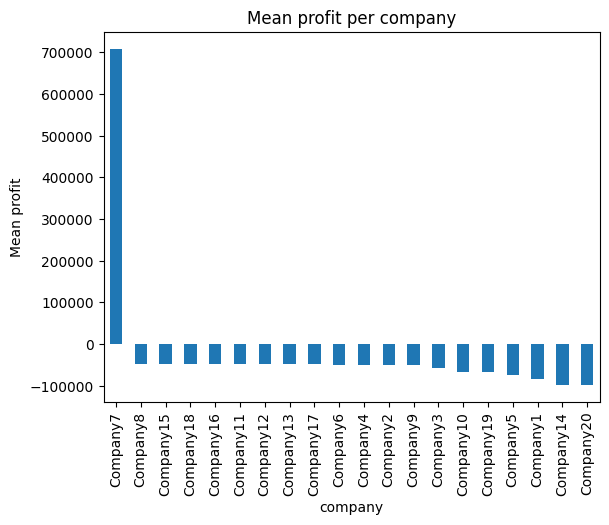

In [17]:
num_simulations = database["file"].nunique()

mean_profit.sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Mean profit")
plt.title("Mean profit per company")
plt.show()

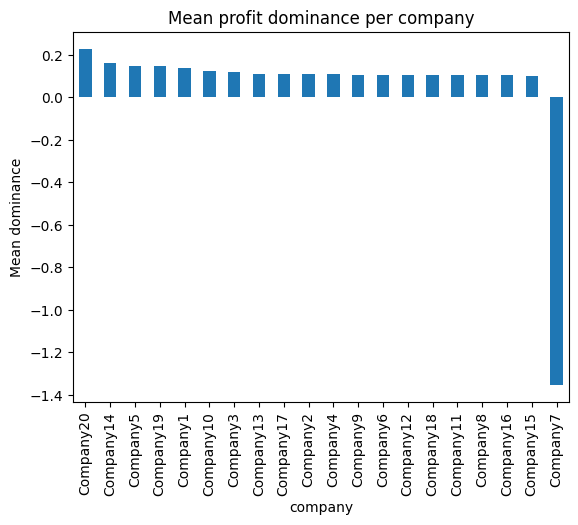

In [18]:
dominance.sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Mean dominance")
plt.title("Mean profit dominance per company")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


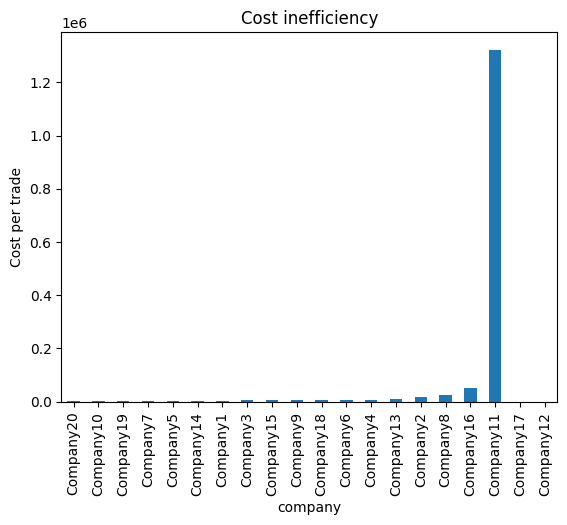

In [19]:
cost_per_trade.sort_values().plot(kind="bar")
plt.ylabel("Cost per trade")
plt.title("Cost inefficiency")
plt.show()

55


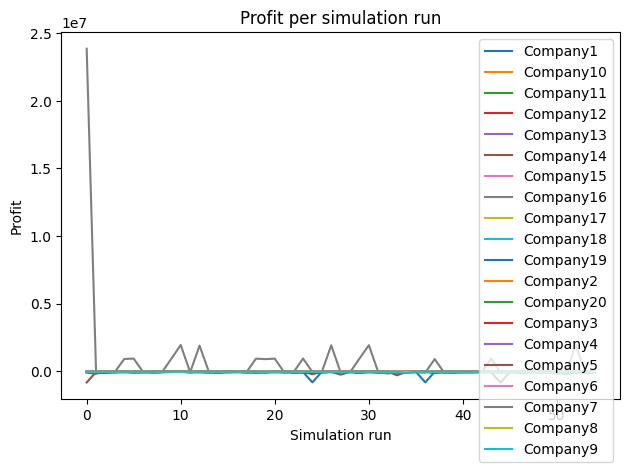

In [20]:
database = database.sort_values(["company", "file"])
database["run_id"] = database.groupby("company").cumcount()
print(database["file"].nunique())

for company, df_c in database.groupby("company"):
    plt.plot(df_c["run_id"], df_c["income"], label=company)

plt.xlabel("Simulation run")
plt.ylabel("Profit")
plt.legend()
plt.title("Profit per simulation run")
plt.tight_layout()



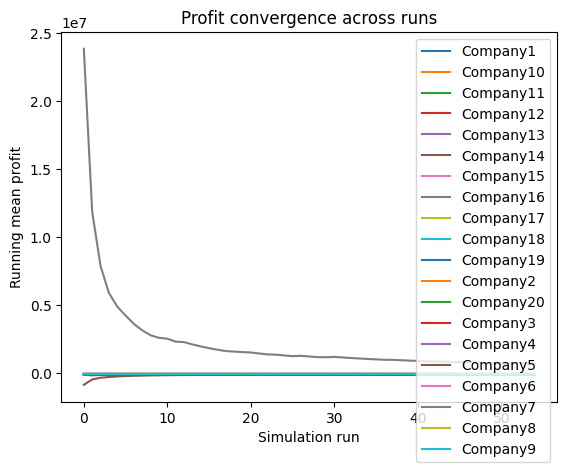

In [21]:
for company, df_c in database.groupby("company"):
    running_mean = df_c["income"].expanding().mean()
    plt.plot(df_c["run_id"], running_mean, label=company)

plt.xlabel("Simulation run")
plt.ylabel("Running mean profit")
plt.legend()
plt.title("Profit convergence across runs")
plt.show()


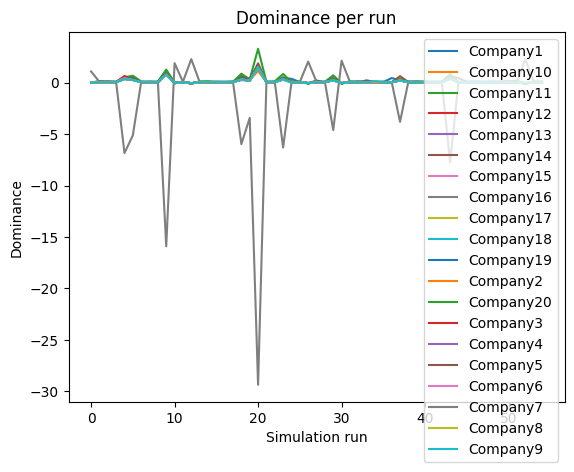

In [22]:
database["run_total"] = database.groupby("file")["income"].transform("sum")
database["dominance"] = database["income"] / database["run_total"]

for company, df_c in database.groupby("company"):
    plt.plot(df_c["run_id"], df_c["dominance"], label=company)

plt.xlabel("Simulation run")
plt.ylabel("Dominance")
plt.legend()
plt.title("Dominance per run")
plt.show()


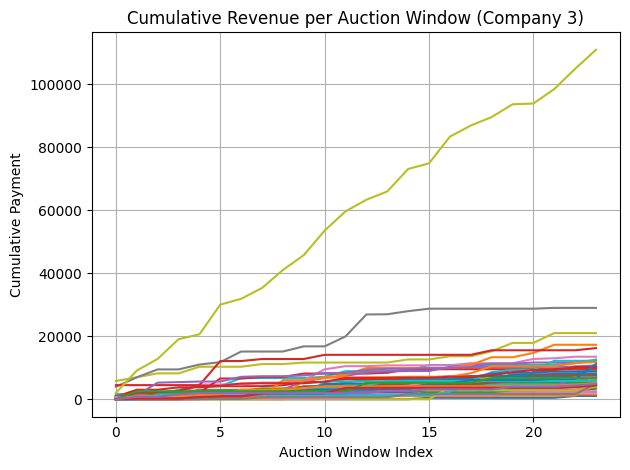

In [23]:
graph()



How is profit influenced by these metrics? Which metrics influences profit the most, and why?

In [24]:
# num_simulations = database["file"].nunique()

# mean_profit.sort_values(ascending=False).plot(kind="bar")
# plt.ylabel("Mean profit")
# plt.title("Mean profit per company")

In [25]:
evaluation_table = pd.concat(
    [
        mean_profit,
        dominance,
        profit_variance,
        worst_profit,
        profit_per_trade,
        cost_per_trade,
        profit_share
    ],
    axis=1,
    keys=[
        "mean_profit",
        "dominance",
        "profit_variance",
        "worst_profit",
        "profit_per_trade",
        "cost_per_trade",
        "profit_share"
    ]
)

evaluation_table

,mean_profit,dominance,profit_variance,worst_profit,profit_per_trade,cost_per_trade,profit_share
company,,,,,,,
Company7,708518.209338,-1.353174,1.053929e+13,-198033.243424,2.179446e+04,1.635807e+03,1.0
Company8,-46669.295614,0.104974,5.756916e+07,-50432.120350,-2.444582e+04,2.566811e+04,1.0
Company15,-47235.995465,0.102204,1.943296e+07,-73108.042916,-4.091307e+03,4.937673e+03,1.0
Company18,-47392.225106,0.106826,3.957030e+07,-51536.443286,-5.385480e+03,6.192317e+03,1.0
Company16,-47779.744814,0.104947,3.591557e+07,-85915.556831,-4.866455e+04,5.149075e+04,1.0
Company11,-48040.838302,0.106600,3.882596e+06,-50508.815633,-1.321123e+06,1.322461e+06,1.0
Company12,-48117.186138,0.107598,3.771737e+06,-50432.120350,-inf,inf,1.0
Company13,-48121.349380,0.111104,5.545310e+07,-99705.687419,-9.158042e+03,1.006240e+04,1.0
Company17,-48472.181550,0.108764,3.649370e+06,-50432.120350,-inf,inf,1.0


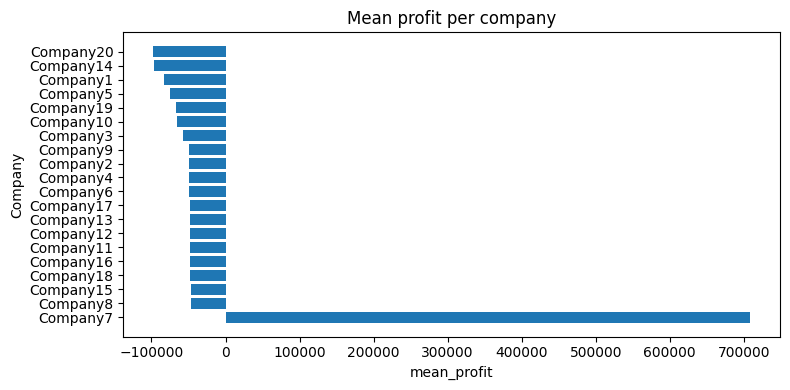

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


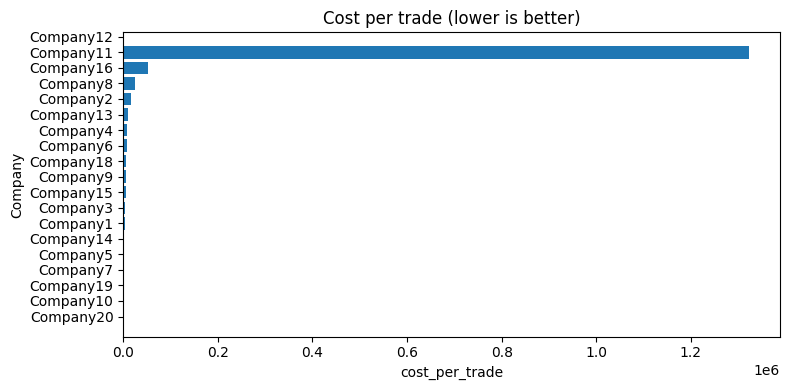

In [ ]:
evaluation_plot = evaluation_table.reset_index()
bar_plot(evaluation_plot, "mean_profit", "Mean profit per company")
bar_plot(evaluation_plot, "cost_per_trade", "Cost per trade (lower is better)", ascending=True)
bar_plot(evaluation_plot, "", "Mean profit per company", ascending=False)
bar_plot(evaluation_plot, "cost_per_trade", "Cost per trade (lower is better)", ascending=True)



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1863: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


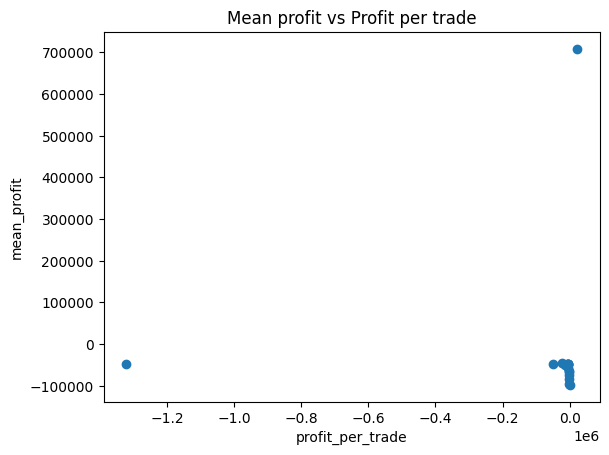

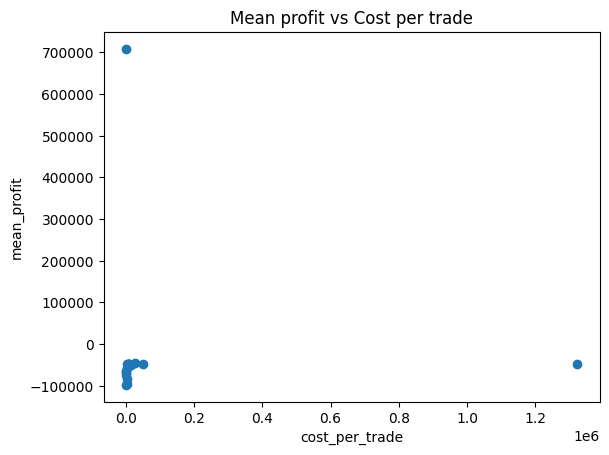

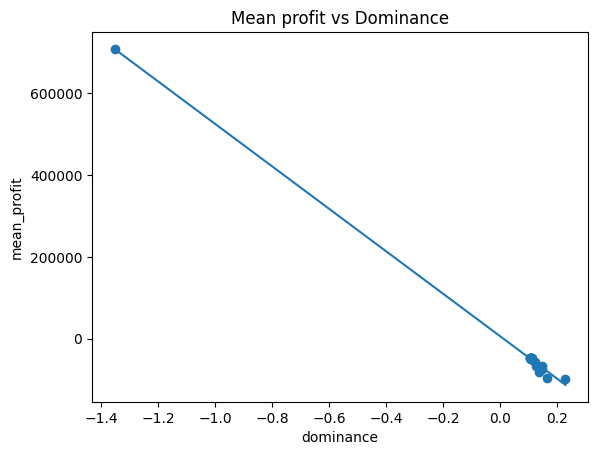

KeyError: 'trades_per_auction'

In [27]:

PAIRS = [
    ("profit_per_trade", "Mean profit vs Profit per trade"),
    ("cost_per_trade", "Mean profit vs Cost per trade"),
    ("dominance", "Mean profit vs Dominance"),
    ("trades_per_auction", "Mean profit vs Trades per auction"),
]

for xcol, title in PAIRS:
    d = filter_outliers(evaluation_table, xcol, "mean_profit")

    x = d[xcol].to_numpy()
    y = d["mean_profit"].to_numpy()

    plt.figure()
    plt.scatter(x, y)

    # Optional linear trend line (only if enough points and x not constant)
    if len(d) >= 2 and np.nanstd(x) > 0:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        plt.plot(xs, m * xs + b)

    plt.xlabel(xcol)
    plt.ylabel("mean_profit")
    plt.title(title)
    plt.show()

In [ ]:
ev = evaluation_table.copy()
ev["company"] = ev.index

PAIRS = [
    ("profit_per_trade", "Mean profit vs Profit per trade"),
    ("cost_per_trade", "Mean profit vs Cost per trade"),
    ("dominance", "Mean profit vs Dominance"),
    ("trades_per_auction", "Mean profit vs Trades per auction"),
]

for xcol, title in PAIRS:
    d = filter_outliers(ev, xcol, "mean_profit")

    fig = px.scatter(
        d,
        x=xcol,
        y="mean_profit",
        hover_name="company",
        title=title
    )
    fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['mean_profit', 'dominance', 'profit_variance', 'worst_profit', 'profit_per_trade', 'cost_per_trade', 'profit_share', 'company'] but received: trades_per_auction

In [ ]:
import geopandas as gpd
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")